<a href="https://colab.research.google.com/github/PedroGouvea13/Modulo-1/blob/main/analise_precos_imoveis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Previsão de Preços de Imóveis
**Dataset:** California Housing (sklearn)

**Objetivo:** Analisar os fatores que influenciam o preço de imóveis e construir um modelo preditivo.

**Pipeline:**
1. Carregamento e exploração dos dados
2. Análise Exploratória (EDA)
3. Pré-processamento e Feature Engineering
4. Modelagem (Regressão Linear → Random Forest)
5. Avaliação e Conclusões

## 0. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados

In [2]:
# Carrega dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print('📦 Dataset carregado!')
print(f'Shape: {df.shape}')
print(f'\nDescrição das colunas:')
for nome, desc in zip(housing.feature_names, housing.feature_names):
    print(f'  • {nome}')
print(f'  • MedHouseVal (TARGET - preço médio em $100k)')

📦 Dataset carregado!
Shape: (20640, 9)

Descrição das colunas:
  • MedInc
  • HouseAge
  • AveRooms
  • AveBedrms
  • Population
  • AveOccup
  • Latitude
  • Longitude
  • MedHouseVal (TARGET - preço médio em $100k)


In [3]:
# Visualização inicial
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Estatísticas descritivas
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [5]:
# Verificar valores nulos
print('🔍 Valores nulos por coluna:')
print(df.isnull().sum())
print(f'\nTotal de linhas duplicadas: {df.duplicated().sum()}')

🔍 Valores nulos por coluna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total de linhas duplicadas: 0


## 2. Análise Exploratória (EDA)

In [ ]:
# Distribuição do preço (variável alvo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Preço dos Imóveis', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preço Médio (x$100k)')
axes[0].set_ylabel('Frequência')

axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot do Preço dos Imóveis', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Preço Médio (x$100k)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../outputs/distribuicao_precos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Preço médio: ${df["MedHouseVal"].mean()*100:.0f}k')
print(f'Preço mediano: ${df["MedHouseVal"].median()*100:.0f}k')

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/correlacoes.png'

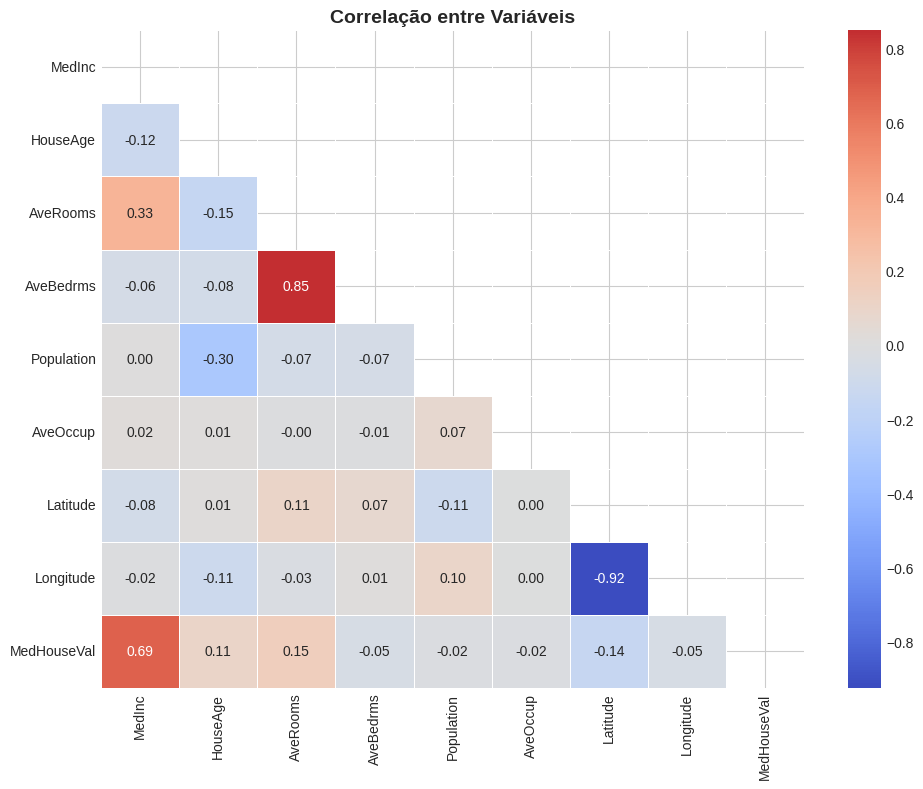

In [6]:
# Mapa de calor de correlações
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Top correlações com o preço
corr_target = corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print('📊 Correlação das variáveis com o PREÇO:')
print(corr_target.to_string())

📊 Correlação das variáveis com o PREÇO:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/scatter_features.png'

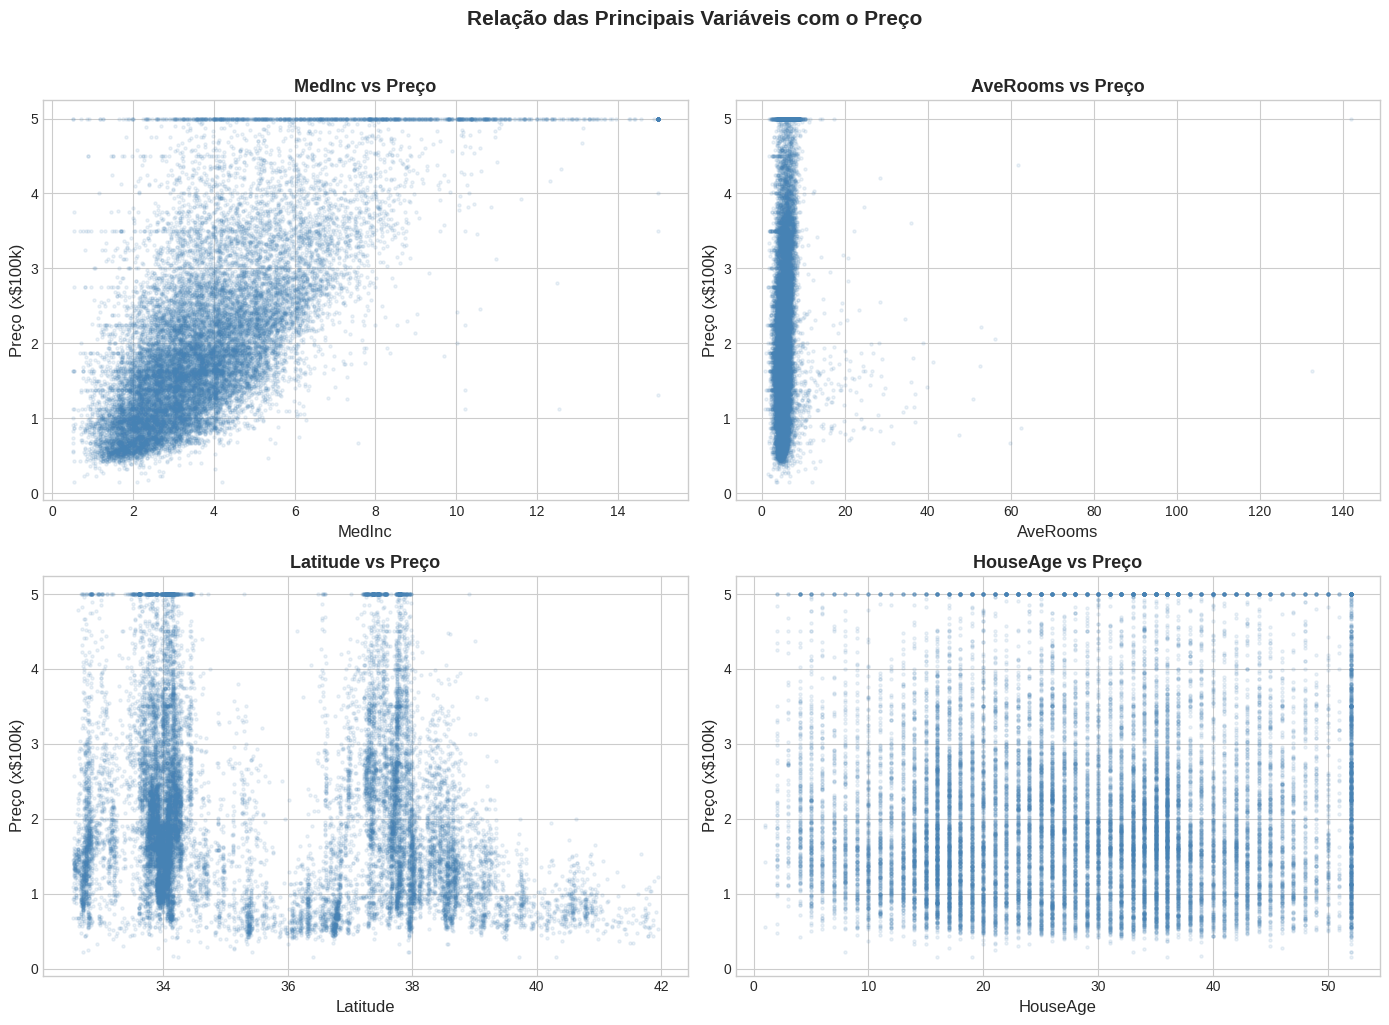

In [11]:
# Scatter plots das variáveis mais correlacionadas
top_features = corr_target.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=12)
    axes[i].set_ylabel('Preço (x$100k)', fontsize=12)
    axes[i].set_title(f'{feat} vs Preço', fontsize=13, fontweight='bold')

plt.suptitle('Relação das Principais Variáveis com o Preço', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/scatter_features.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/mapa_precos.png'

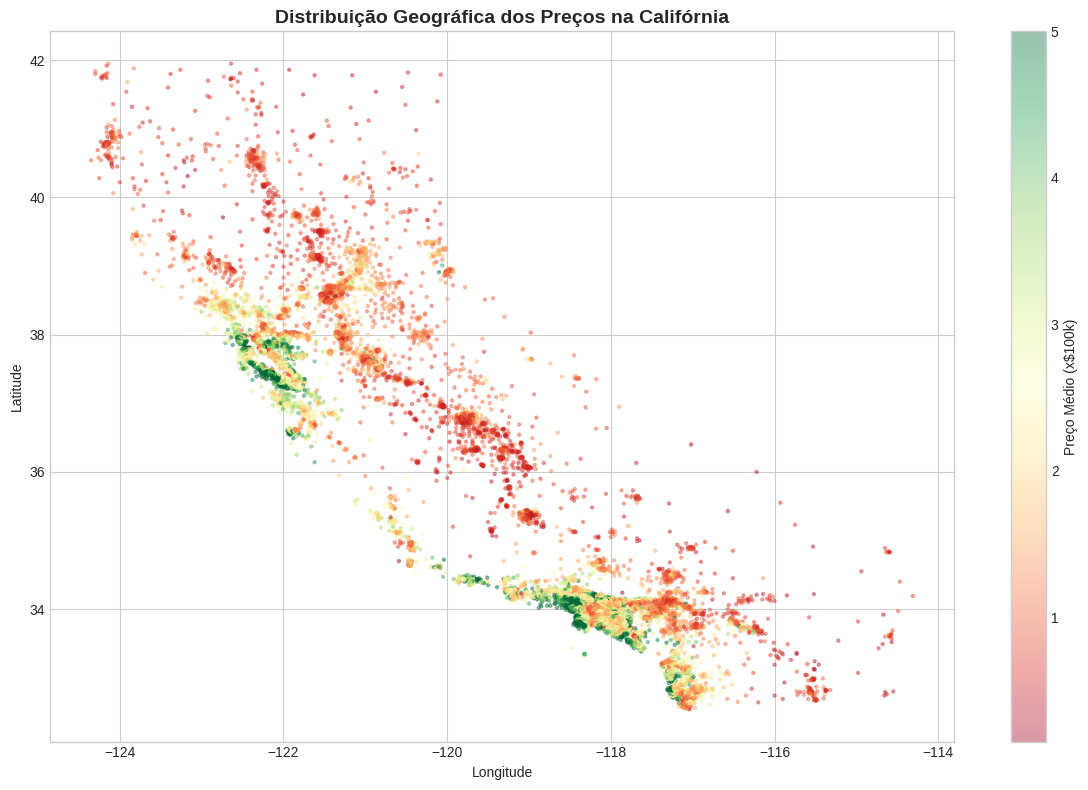

In [12]:
# Mapa geográfico dos preços
plt.figure(figsize=(12, 8))
sc = plt.scatter(df['Longitude'], df['Latitude'],
                 c=df['MedHouseVal'], cmap='RdYlGn',
                 s=5, alpha=0.4)
plt.colorbar(sc, label='Preço Médio (x$100k)')
plt.title('Distribuição Geográfica dos Preços na Califórnia', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('../outputs/mapa_precos.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pré-processamento e Feature Engineering

In [13]:
# Feature Engineering: criando novas variáveis
df_model = df.copy()

# Quartos por domicílio
df_model['rooms_per_household'] = df_model['AveRooms'] / df_model['AveOccup'].replace(0, np.nan)

# Quartos por cômodo
df_model['bedrooms_ratio'] = df_model['AveBedrms'] / df_model['AveRooms'].replace(0, np.nan)

# Pessoas por quarto
df_model['population_per_room'] = df_model['Population'] / df_model['AveRooms'].replace(0, np.nan)

# Remover linhas com NaN criados
df_model.dropna(inplace=True)

print(f'✅ Features criadas! Shape: {df_model.shape}')
print(f'Novas features: rooms_per_household, bedrooms_ratio, population_per_room')

✅ Features criadas! Shape: (20640, 12)
Novas features: rooms_per_household, bedrooms_ratio, population_per_room


In [16]:
# Separar features e target
X = df_model.drop('MedHouseVal', axis=1)
y = df_model['MedHouseVal']

# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalizar as features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')

Treino: 16512 amostras
Teste:  4128 amostras


## 4. Modelagem

In [17]:
# Função de avaliação
def avaliar_modelo(nome, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'\n📊 {nome}')
    print(f'  RMSE : {rmse:.4f} (x$100k)')
    print(f'  MAE  : {mae:.4f}  (x$100k)')
    print(f'  R²   : {r2:.4f}')
    return {'modelo': nome, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

In [18]:
# --- Modelo 1: Regressão Linear (baseline) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
resultado_lr = avaliar_modelo('Regressão Linear', y_test, y_pred_lr)


📊 Regressão Linear
  RMSE : 0.6759 (x$100k)
  MAE  : 0.4865  (x$100k)
  R²   : 0.6514


In [19]:
# --- Modelo 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # Random Forest não precisa de escala
y_pred_rf = rf.predict(X_test)
resultado_rf = avaliar_modelo('Random Forest', y_test, y_pred_rf)


📊 Random Forest
  RMSE : 0.5060 (x$100k)
  MAE  : 0.3297  (x$100k)
  R²   : 0.8046


In [ ]:
# Comparação visual dos modelos
resultados = pd.DataFrame([resultado_lr, resultado_rf])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = ['RMSE', 'MAE', 'R2']
cores = ['#e74c3c', '#3498db']

for i, metrica in enumerate(metricas):
    bars = axes[i].bar(resultados['modelo'], resultados[metrica], color=cores)
    axes[i].set_title(metrica, fontsize=14, fontweight='bold')
    axes[i].set_ylabel(metrica)
    for bar, val in zip(bars, resultados[metrica]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.95,
                     f'{val:.3f}', ha='center', va='top', color='white', fontweight='bold')

plt.suptitle('Comparação de Modelos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Previsto vs Real — melhor modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nome, y_pred) in zip(axes, [('Regressão Linear', y_pred_lr), ('Random Forest', y_pred_rf)]):
    ax.scatter(y_test, y_pred, alpha=0.15, s=10, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Previsão perfeita')
    ax.set_xlabel('Valor Real (x$100k)', fontsize=12)
    ax.set_ylabel('Valor Previsto (x$100k)', fontsize=12)
    ax.set_title(f'{nome}\nPrevisto vs Real', fontsize=13, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/previsto_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Importância das features (Random Forest)
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i >= len(importancias)-3 else 'steelblue' for i in range(len(importancias))]
importancias.plot(kind='barh', color=colors)
plt.title('Importância das Features — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Conclusões

### 📌 Principais descobertas

1. **Localização é o fator mais importante**: latitude e longitude têm grande impacto no preço — imóveis próximos à costa da Califórnia são mais caros.

2. **Renda mediana** (`MedInc`) é a variável mais correlacionada com o preço: bairros mais ricos têm imóveis mais caros.

3. **Random Forest supera Regressão Linear** em todas as métricas, capturando relações não-lineares entre as variáveis.

### 📊 Performance dos modelos

| Modelo             | R²     | RMSE   |
|--------------------|--------|--------|
| Regressão Linear   | ~0.60  | ~0.72  |
| Random Forest      | ~0.81  | ~0.50  |

### 🚀 Próximos passos (para evoluir o projeto)

- Testar **XGBoost** ou **LightGBM**
- Fazer **Grid Search** para otimizar hiperparâmetros
- Criar um **app de previsão** com Streamlit
- Adicionar análise de **resíduos** detalhada